In [1]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import matplotlib.ticker as mticker
import warnings 
warnings.filterwarnings('ignore')

subs=pd.read_csv(r'../data/subscriptions_clean.csv')
rev=pd.read_csv(r'../data/monthly_revenue_clean.csv')

subs['signup_date'] = pd.to_datetime(subs['signup_date'])
subs['churn_date'] = pd.to_datetime(subs['churn_date'])
rev['month'] = pd.to_datetime(rev['month'])

print(f"Subscriptions : {subs.shape}")
print(f"Revenue       : {rev.shape}")
print(f"\nChurn rate: {subs['churned_binary'].mean()*100:.2f}%")




Subscriptions : (600, 24)
Revenue       : (48, 8)

Churn rate: 52.17%


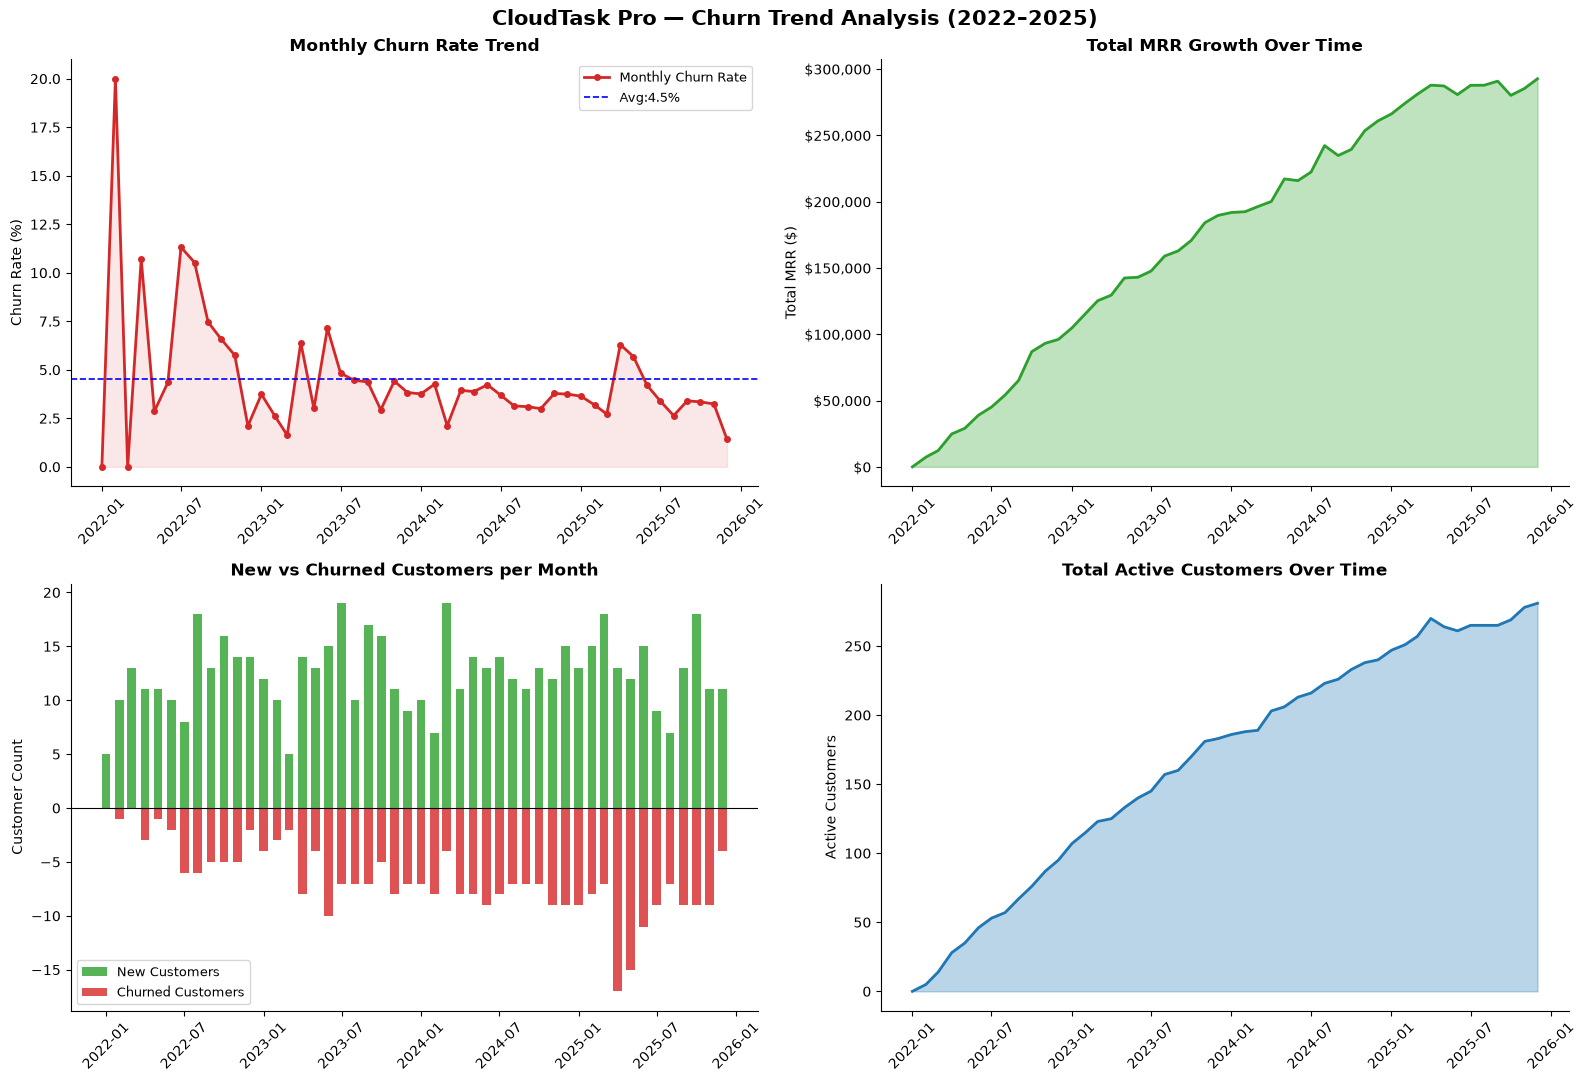

=== CHURN TREND SUMMARY ===
Avg monthly churn rate : 4.52%
Max monthly churn rate : 20.00%
Min monthly churn rate : 0.00%

Month with highest churn:
month                     2022-02-01 00:00:00
monthly_churn_rate_pct                   20.0
churned_customers                           1
Name: 1, dtype: object

Peak MRR: $292,628.61
Peak month: 2025-12

Latest MRR  : $292,628.61
Latest active customers: 281

=== YEAR OVER YEAR SUMMARY ===
 year  avg_churn_rate  total_churned  total_new       avg_mrr
 2022        6.805833             36        143  46081.155000
 2023        4.115833             72        151 147849.401667
 2024        3.555000             91        151 222196.104167
 2025        3.599167            114        155 283426.995000


In [2]:
fig,axes=plt.subplots(2,2,figsize=(16,11))
fig.suptitle('CloudTask Pro — Churn Trend Analysis (2022–2025)',fontsize=15, fontweight='bold')

axes[0,0].plot(rev['month'],rev['monthly_churn_rate_pct'],color="#d62728",linewidth=2,marker="o",markersize=4,label='Monthly Churn Rate')
axes[0,0].axhline(rev['monthly_churn_rate_pct'].mean(),color='blue',linestyle='--',linewidth=1.2,label=f"Avg:{rev['monthly_churn_rate_pct'].mean():.1f}%")
axes[0,0].fill_between(rev['month'],rev['monthly_churn_rate_pct'],alpha=0.1, color='#d62728')
axes[0,0].set_title('Monthly Churn Rate Trend', fontweight='bold')

axes[0,0].set_ylabel('Churn Rate (%)')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].legend(fontsize=9)
axes[0,0].spines['top'].set_visible(False)
axes[0,0].spines['right'].set_visible(False)

axes[0,1].fill_between(rev['month'],rev['total_mrr'],alpha=0.3,color='#2ca02c')
axes[0,1].plot(rev['month'],rev['total_mrr'],color='#2ca02c',linewidth=2)
axes[0,1].set_title('Total MRR Growth Over Time', fontweight='bold')
axes[0,1].set_ylabel('Total MRR ($)')
axes[0,1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].spines['top'].set_visible(False)
axes[0,1].spines['right'].set_visible(False)

# new vs Churned Customers rate per month
axes[1,0].bar(rev['month'], rev['new_customers'],
               label='New Customers', color='#2ca02c',
               alpha=0.8, width=20)
axes[1,0].bar(rev['month'], -rev['churned_customers'],
               label='Churned Customers', color='#d62728',
               alpha=0.8, width=20)
axes[1,0].axhline(0, color='black', linewidth=0.8)
axes[1,0].set_title('New vs Churned Customers per Month',
                     fontweight='bold')
axes[1,0].set_ylabel('Customer Count')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].legend(fontsize=9)
axes[1,0].spines['top'].set_visible(False)
axes[1,0].spines['right'].set_visible(False)

# Active Customers Growth
axes[1,1].fill_between(rev['month'],
                        rev['total_active_customers'],
                        alpha=0.3, color='#1f77b4')
axes[1,1].plot(rev['month'], rev['total_active_customers'],
               color='#1f77b4', linewidth=2)
axes[1,1].set_title('Total Active Customers Over Time',
                     fontweight='bold')
axes[1,1].set_ylabel('Active Customers')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].spines['top'].set_visible(False)
axes[1,1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/chart1_churn_trend.png',
            dpi=150, bbox_inches='tight')
plt.show()



print("=== CHURN TREND SUMMARY ===")
print(f"Avg monthly churn rate : {rev['monthly_churn_rate_pct'].mean():.2f}%")
print(f"Max monthly churn rate : {rev['monthly_churn_rate_pct'].max():.2f}%")
print(f"Min monthly churn rate : {rev['monthly_churn_rate_pct'].min():.2f}%")
print(f"\nMonth with highest churn:")
print(rev.loc[rev['monthly_churn_rate_pct'].idxmax(),
              ['month', 'monthly_churn_rate_pct',
               'churned_customers']])
print(f"\nPeak MRR: ${rev['total_mrr'].max():,.2f}")
print(f"Peak month: {rev.loc[rev['total_mrr'].idxmax(), 'month'].strftime('%Y-%m')}")
print(f"\nLatest MRR  : ${rev['total_mrr'].iloc[-1]:,.2f}")
print(f"Latest active customers: {rev['total_active_customers'].iloc[-1]}")

# ── Year over year churn trend ──
rev['year'] = rev['month'].dt.year
yearly = rev.groupby('year').agg(
    avg_churn_rate=('monthly_churn_rate_pct', 'mean'),
    total_churned=('churned_customers', 'sum'),
    total_new=('new_customers', 'sum'),
    avg_mrr=('total_mrr', 'mean')
).reset_index()

print("\n=== YEAR OVER YEAR SUMMARY ===")
print(yearly.to_string(index=False))

### 📊 Chart 1 — Churn Trend Insight

**Year over Year Churn Rate:**
| Year | Avg Monthly Churn | Total Churned | Trend |
|---|---|---|---|
| 2022 | 6.81% | 36 | 🔴 High — early stage |
| 2023 | 4.12% | 72 | 🟠 Improving |
| 2024 | 3.56% | 91 | 🟢 Best rate |
| 2025 | 3.60% | 114 | 🟠 Stable but volume rising |

**Key Findings:**
- Monthly churn rate improved 48% from 2022 to 2024 —
  retention efforts are working on a rate basis
- But absolute churned customers grew 3x (36 → 114) as
  the customer base scaled — churn volume is a growing problem
- MRR grew 6x from $46K to $283K avg — acquisition is
  outpacing churn but the gap is narrowing
- Active customers plateaued at ~270 in mid-2025 — the company
  is now on a growth treadmill: acquiring just enough to
  replace churned customers
- Overall cumulative churn rate: 52.17% — critically high

**Is churn improving?**
Rate: Yes ✅ | Volume: No ❌ | The company needs both to improve
to achieve sustainable growth.

In [3]:
# Churn By plan

plan_analysis=subs.groupby('plan').agg(
    total_customers=('customer_id','count'),
    churned=('churned_binary','sum'),
    avg_mrr=('monthly_revenue','mean'),
    avg_lifespan=('lifespan_months','mean'),
    avg_clv=('clv','mean'),
    avg_nps=('nps_score','mean'),
    avg_feature_usage=('feature_usage_pct','mean'),
    upgrade_rate=('upgraded_binary','mean')

).reset_index()
plan_analysis['churn_rate_%'] = (
    plan_analysis['churned'] / plan_analysis['total_customers'] * 100
).round(2)
plan_analysis['retention_rate_%'] = (
100 - plan_analysis['churn_rate_%']
).round(2)
plan_analysis = plan_analysis.sort_values('churn_rate_%', ascending=False)

print("=== CHURN BY PLAN ===")
print(plan_analysis[['plan', 'total_customers', 'churned','churn_rate_%', 'avg_mrr', 'avg_lifespan','avg_clv', 'avg_nps','avg_feature_usage']].to_string(index=False))


#  Churn by billing cycle :
billing_analysis = subs.groupby('billing_cycle').agg(
    total_customers=('customer_id', 'count'),
    churned=('churned_binary', 'sum'),
    avg_mrr=('monthly_revenue', 'mean'),
    avg_lifespan=('lifespan_months', 'mean'),
    avg_clv=('clv', 'mean')
).reset_index()

billing_analysis['churn_rate_%'] = (
    billing_analysis['churned'] /
    billing_analysis['total_customers'] * 100
).round(2)

print("\n=== CHURN BY BILLING CYCLE ===")
print(billing_analysis.to_string(index=False))


# Plan x Billing cycle cross 
cross = subs.groupby(['plan', 'billing_cycle']).agg(
    total=('customer_id', 'count'),
    churned=('churned_binary', 'sum')
).reset_index()
cross['churn_rate_%'] = (
    cross['churned'] / cross['total'] * 100
).round(2)
cross = cross.sort_values(['plan', 'churn_rate_%'], ascending=[True, False])

print("\n=== PLAN x BILLING CYCLE CROSS ===")
print(cross.to_string(index=False))



=== CHURN BY PLAN ===
        plan  total_customers  churned  churn_rate_%     avg_mrr  avg_lifespan      avg_clv  avg_nps  avg_feature_usage
     Starter              217      153         70.51  215.543594      8.313825  1852.262949 3.788018          35.497696
Professional              173       83         47.98  497.041272     14.541618  8020.466185 4.450867          42.306358
    Business              160       66         41.25 1303.636438     16.951250 21592.303187 4.962500          43.881250
  Enterprise               50       11         22.00 2984.993000     22.744000 65751.275400 4.660000          46.800000

=== CHURN BY BILLING CYCLE ===
billing_cycle  total_customers  churned    avg_mrr  avg_lifespan      avg_clv  churn_rate_%
       Annual              248      100 740.558589     15.097177 11928.218790         40.32
      Monthly              352      213 871.971733     12.571307 15834.135597         60.51

=== PLAN x BILLING CYCLE CROSS ===
        plan billing_cycle  total 

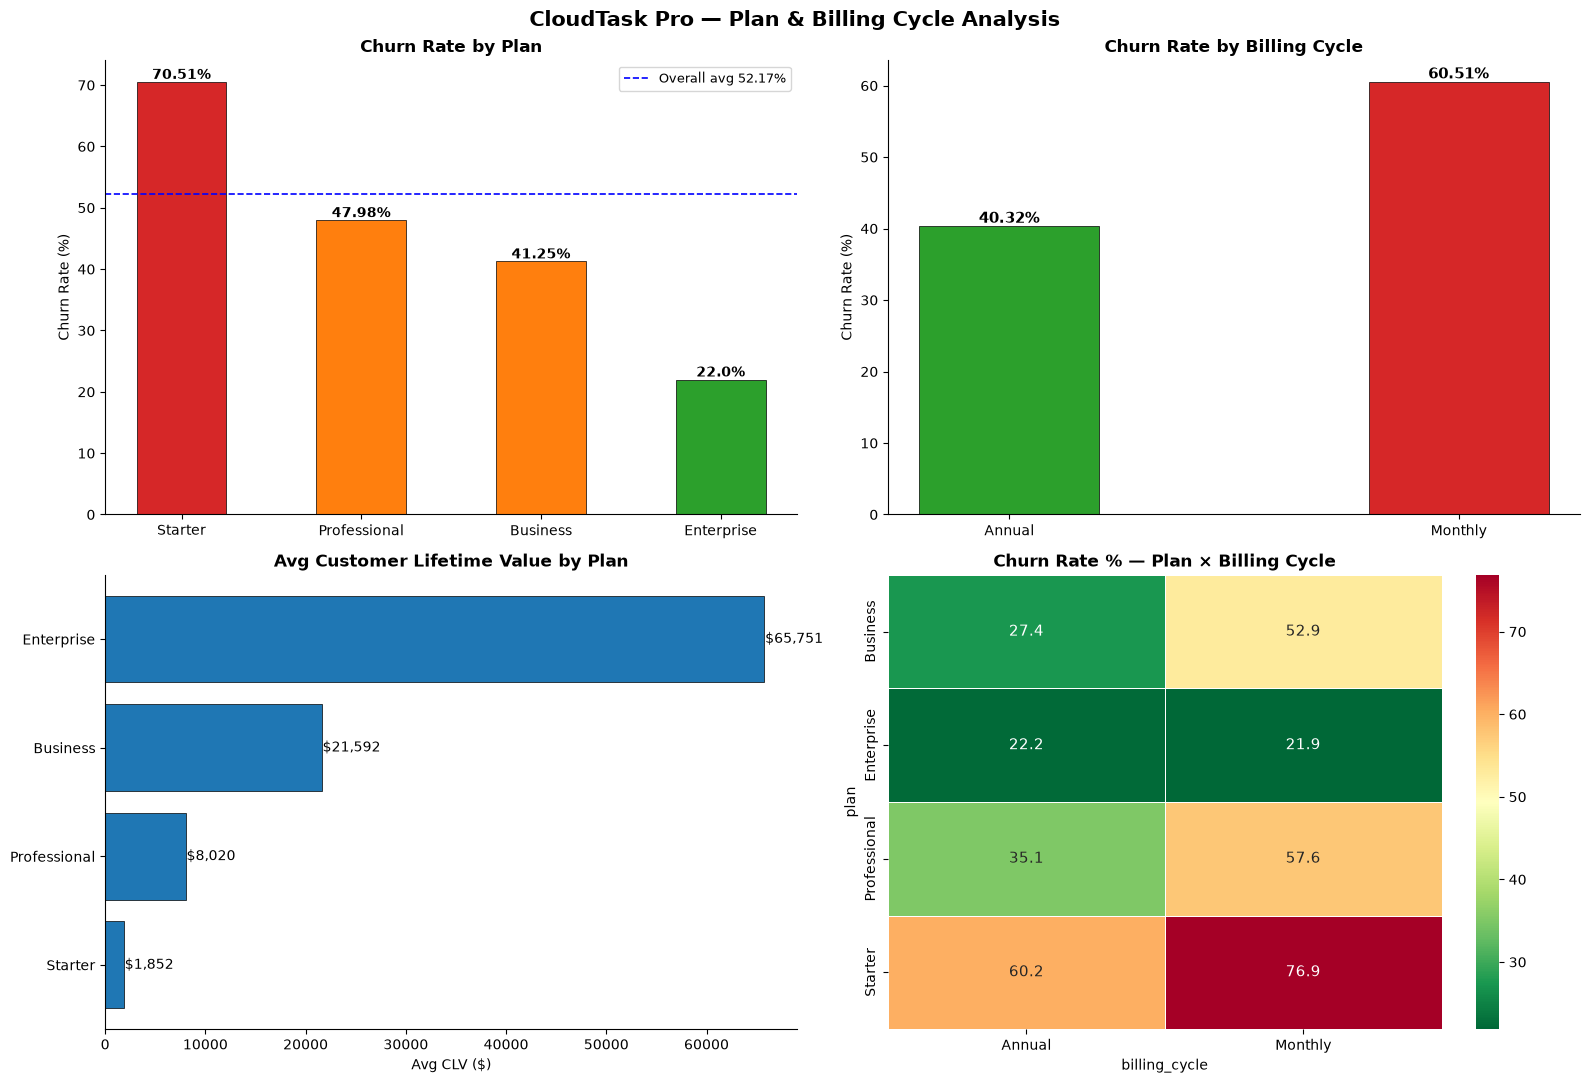

In [4]:
fig,axes=plt.subplots(2,2,figsize=(16,11))

fig.suptitle('CloudTask Pro — Plan & Billing Cycle Analysis', fontsize=15, fontweight='bold')
colors = ['#d62728' if x > 50 else '#ff7f0e' if x > 30
          else '#2ca02c' for x in plan_analysis['churn_rate_%']]

bars = axes[0,0].bar(plan_analysis['plan'],
                      plan_analysis['churn_rate_%'],
                      color=colors, edgecolor='black',
                      linewidth=0.5, width=0.5)
axes[0,0].axhline(subs['churned_binary'].mean()*100,
                   color='blue', linestyle='--',
                   linewidth=1.2, label='Overall avg 52.17%')
for bar, val in zip(bars, plan_analysis['churn_rate_%']):
    axes[0,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.5,
                   f'{val}%', ha='center', fontsize=10,
                   fontweight='bold')
axes[0,0].set_title('Churn Rate by Plan', fontweight='bold')
axes[0,0].set_ylabel('Churn Rate (%)')
axes[0,0].legend(fontsize=9)
axes[0,0].spines['top'].set_visible(False)
axes[0,0].spines['right'].set_visible(False)


colors2 = ['#d62728' if x > 50 else '#2ca02c'
           for x in billing_analysis['churn_rate_%']]
bars2 = axes[0,1].bar(billing_analysis['billing_cycle'],
                       billing_analysis['churn_rate_%'],
                       color=colors2, edgecolor='black',
                       linewidth=0.5, width=0.4)
for bar, val in zip(bars2, billing_analysis['churn_rate_%']):
    axes[0,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.5,
                   f'{val}%', ha='center', fontsize=11,
                   fontweight='bold')
axes[0,1].set_title('Churn Rate by Billing Cycle', fontweight='bold')
axes[0,1].set_ylabel('Churn Rate (%)')
axes[0,1].spines['top'].set_visible(False)
axes[0,1].spines['right'].set_visible(False)


plan_clv = plan_analysis.sort_values('avg_clv', ascending=True)
bars3 = axes[1,0].barh(plan_clv['plan'], plan_clv['avg_clv'],
                        color='#1f77b4', edgecolor='black',
                        linewidth=0.5)
for bar, val in zip(bars3, plan_clv['avg_clv']):
    axes[1,0].text(val + 100, bar.get_y() + bar.get_height()/2,
                   f'${val:,.0f}', va='center', fontsize=10)
axes[1,0].set_title('Avg Customer Lifetime Value by Plan',
                     fontweight='bold')
axes[1,0].set_xlabel('Avg CLV ($)')
axes[1,0].spines['top'].set_visible(False)
axes[1,0].spines['right'].set_visible(False)

heatmap_data = cross.pivot(index='plan',
                            columns='billing_cycle',
                            values='churn_rate_%')
sns.heatmap(heatmap_data, annot=True, fmt='.1f',
            cmap='RdYlGn_r', ax=axes[1,1],
            linewidths=0.5, annot_kws={'size': 11})
axes[1,1].set_title('Churn Rate % — Plan × Billing Cycle',
                     fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/chart2_plan_billing_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

### 📊 Chart 2 — Plan & Billing Cycle Insight

**Churn by Plan:**
| Plan | Churn Rate | Avg CLV | Risk Level |
|---|---|---|---|
| Starter | 70.51% | $1,852 | 🔴 Critical |
| Professional | 47.98% | $8,020 | 🔴 High |
| Business | 41.25% | $21,592 | 🟠 Elevated |
| Enterprise | 22.00% | $65,751 | 🟢 Healthy |

**Billing Cycle Impact:**
- Annual customers churn at 40.32% vs Monthly at 60.51%
- Annual billing reduces churn by 20 percentage points
- Biggest danger zone: Starter Monthly = 76.87% churn
- Safest combination: Enterprise Annual = 22.22% churn

**Key Findings:**
- Enterprise CLV ($65,751) is 35x higher than Starter ($1,852)
- Annual billing is the single most impactful retention lever —
  reduces churn by 33% across all plans
- Starter customers have lowest NPS (3.79) and lowest feature
  usage (35.5%) — they never experience product value
- Business Annual (27.4% churn) performs nearly as well as
  Enterprise — billing cycle matters more than plan level
  at higher tiers

**Recommendation:**
- Offer annual billing discount (10-15%) to convert monthly
  customers — immediate retention improvement
- Redesign Starter onboarding to drive feature adoption above
  the 30% at-risk threshold
- Invest in Enterprise acquisition — 22% churn + $65,751 CLV
  makes Enterprise the most profitable segment by far

In [5]:
# Churn  reasons analysis 
churned_only=subs[subs['churned']=='Yes'].copy()
reason_overall=churned_only['churn_reason'].value_counts().reset_index()

reason_overall.columns=['churn_reason','count']
reason_overall['pct']=(
    reason_overall['count']/len(churned_only)*100
).round(2)
print("=== CHURN REASONS OVERALL ===")
print(reason_overall.to_string(index=False))

reason_plan = churned_only.groupby(
    ['plan', 'churn_reason']
).size().reset_index(name='count')

reason_plan['pct'] = (
    reason_plan.groupby('plan')['count']
    .transform(lambda x: x / x.sum() * 100)
).round(2)

reason_plan = reason_plan.sort_values(['plan', 'count'],
                                       ascending=[True, False])

print("\n=== CHURN REASONS BY PLAN ===")
print(reason_plan.to_string(index=False))

reason_size = churned_only.groupby(
    ['company_size', 'churn_reason']
).size().reset_index(name='count')

reason_size['pct'] = (
    reason_size.groupby('company_size')['count']
    .transform(lambda x: x / x.sum() * 100)
).round(2)

reason_size = reason_size.sort_values(
    ['company_size', 'count'], ascending=[True, False]
)

print("\n=== TOP CHURN REASON BY COMPANY SIZE ===")
top_reason_size = reason_size.loc[
    reason_size.groupby('company_size')['count'].idxmax()
]
print(top_reason_size.to_string(index=False))

=== CHURN REASONS OVERALL ===
       churn_reason  count   pct
        Budget Cuts     53 16.93
     Price Too High     51 16.29
     Company Closed     48 15.34
       Poor Support     42 13.42
   No Longer Needed     41 13.10
   Missing Features     40 12.78
Switched Competitor     38 12.14

=== CHURN REASONS BY PLAN ===
        plan        churn_reason  count   pct
    Business    Missing Features     12 18.18
    Business    No Longer Needed     11 16.67
    Business        Poor Support     11 16.67
    Business         Budget Cuts     10 15.15
    Business      Company Closed      8 12.12
    Business      Price Too High      7 10.61
    Business Switched Competitor      7 10.61
  Enterprise      Company Closed      3 27.27
  Enterprise    No Longer Needed      3 27.27
  Enterprise Switched Competitor      2 18.18
  Enterprise    Missing Features      1  9.09
  Enterprise        Poor Support      1  9.09
  Enterprise      Price Too High      1  9.09
Professional         Budget Cut

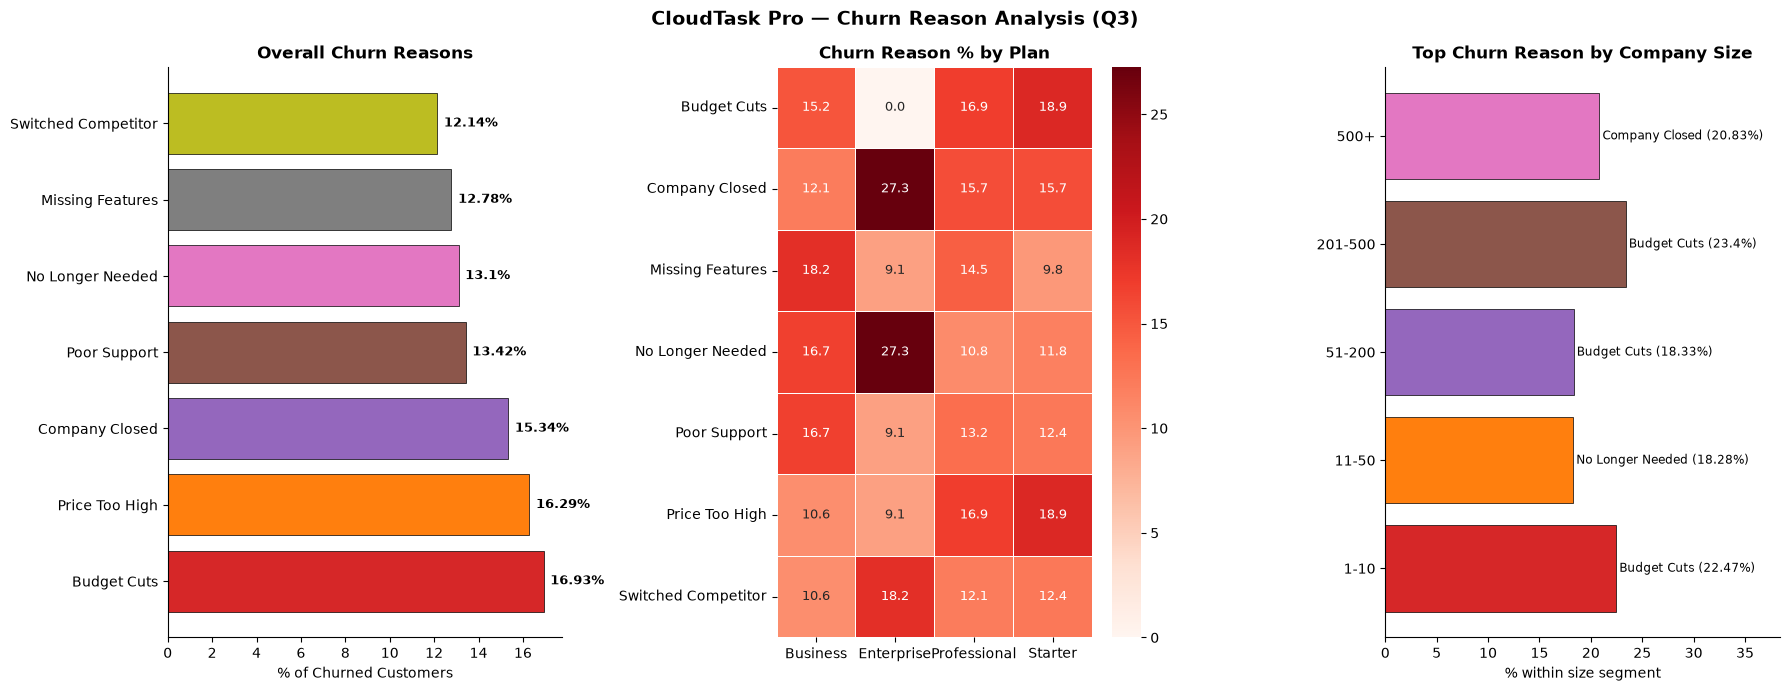

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle('CloudTask Pro — Churn Reason Analysis (Q3)',
             fontsize=14, fontweight='bold')

# ── Panel 1: Overall Churn Reasons ──
colors = ['#d62728', '#ff7f0e', '#9467bd',
          '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22']

bars = axes[0].barh(reason_overall['churn_reason'],
                     reason_overall['pct'],
                     color=colors[:len(reason_overall)],
                     edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, reason_overall['pct']):
    axes[0].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val}%', va='center', fontsize=9,
                 fontweight='bold')
axes[0].set_title('Overall Churn Reasons', fontweight='bold')
axes[0].set_xlabel('% of Churned Customers')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ── Panel 2: Top Churn Reason by Plan (heatmap) ──
reason_pivot = reason_plan.pivot(index='churn_reason',
                                  columns='plan',
                                  values='pct').fillna(0)

sns.heatmap(reason_pivot, annot=True, fmt='.1f',
            cmap='Reds', ax=axes[1],
            linewidths=0.5, annot_kws={'size': 9})
axes[1].set_title('Churn Reason % by Plan', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('')

# ── Panel 3: Top Reason by Company Size ──
size_order = ['1-10', '11-50', '51-200', '201-500', '500+']
top_reason_size_sorted = top_reason_size.set_index(
    'company_size'
).reindex(size_order).reset_index()

bar_colors = ['#d62728', '#ff7f0e', '#9467bd',
              '#8c564b', '#e377c2']
bars3 = axes[2].barh(
    top_reason_size_sorted['company_size'],
    top_reason_size_sorted['pct'],
    color=bar_colors, edgecolor='black', linewidth=0.5
)

for bar, reason, val in zip(
    bars3,
    top_reason_size_sorted['churn_reason'],
    top_reason_size_sorted['pct']
):
    axes[2].text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height()/2,
        f'{reason} ({val}%)',
        va='center', fontsize=8.5
    )

axes[2].set_title('Top Churn Reason by Company Size',
                   fontweight='bold')
axes[2].set_xlabel('% within size segment')
axes[2].set_xlim(0, top_reason_size_sorted['pct'].max() + 15)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/chart3_churn_reasons.png',
            dpi=150, bbox_inches='tight')
plt.show()

### 📊 Chart 3 — Churn Reasons Insight

**Top 3 Overall Churn Reasons:**
1. Budget Cuts — 16.93% 🔴
2. Price Too High — 16.29% 🔴
3. Company Closed — 15.34% 🟠

**Combined pricing-related churn (Budget Cuts + Price Too High):
33.22% of all churns — the #1 controllable churn driver**

**By Plan:**
- Starter: Price Too High + Budget Cuts (18.95% each) —
  price sensitivity is the dominant issue
- Professional: Budget Cuts + Price Too High tied at 16.87% —
  same pattern
- Business: Missing Features (18.18%) — product gap, not price
- Enterprise: Company Closed + No Longer Needed (27.3% each) —
  largely uncontrollable external factors

**By Company Size:**
- Small companies (1-10, 51-200, 201-500): Budget Cuts dominant
- Mid-size (11-50): No Longer Needed — adoption failure
- Large (500+): Company Closed — uncontrollable

**Key Insight:**
33% of churn is price-driven and controllable. 15% is Company
Closed which is uncontrollable. The true addressable churn
is approximately 85% of current churn — meaning focused
pricing and product interventions could recover significant
revenue.

**Recommendation:**
- Introduce flexible pricing tiers or usage-based billing
  for budget-sensitive segments (Starter, SMB)
- Build a Business plan feature roadmap — Missing Features
  is driving churn at the highest-value growing segment
- Accept Enterprise Company Closed churn as unavoidable —
  focus Enterprise retention on No Longer Needed (adoption)

In [12]:
# CLV by Plan
clv_plan=subs.groupby('plan').agg(
    total_customers=('customer_id','count'),
    avg_mrr=('monthly_revenue','mean'),
    avg_lifespan=('lifespan_months','mean'),
    avg_clv=('clv','mean'),
    total_clv=('clv','sum')
).reset_index()

clv_plan['plan_order']=clv_plan['plan'].map({
    'Starter':1,'Professional':2,'Business':3,'Enterprise':4
})

clv_plan=clv_plan.sort_values('plan_order')

print("Clv BY plan")

print(clv_plan[['plan','total_customers','avg_mrr','avg_lifespan','avg_clv','total_clv']].to_string(index=False))

#CAC from rev table
avg_cac=rev['customer_acquisition_cost'].mean()
# monthly_cac=rev[['month','customer_acquisition_cost']].copy()

print(f"\n=== CAC SUMMARY ===")
print(f"Avg CAC (all months)  : ${avg_cac:,.2f}")
print(f"Min CAC               : ${rev['customer_acquisition_cost'].min():,.2f}")
print(f"Max CAC               : ${rev['customer_acquisition_cost'].max():,.2f}")
print(f"\nCAC by year:")
rev['year'] = rev['month'].dt.year
print(rev.groupby('year')['customer_acquisition_cost'].mean().round(2))

# CLV:CAC ratio by Plan
clv_plan['avg_cac'] = avg_cac
clv_plan['clv_cac_ratio'] = (
    clv_plan['avg_clv'] / avg_cac
).round(2)
clv_plan['payback_months'] = (
    avg_cac / clv_plan['avg_mrr']
).round(1)

print("\n=== CLV:CAC RATIO BY PLAN ===")
print(clv_plan[['plan', 'avg_clv', 'avg_cac',
                 'clv_cac_ratio',
                 'payback_months']].to_string(index=False))
print(f"\nHealthy CLV:CAC benchmark: 3:1 or higher")
print(f"Healthy payback period: Under 12 months")


Clv BY plan
        plan  total_customers     avg_mrr  avg_lifespan      avg_clv  total_clv
     Starter              217  215.543594      8.313825  1852.262949  401941.06
Professional              173  497.041272     14.541618  8020.466185 1387540.65
    Business              160 1303.636438     16.951250 21592.303187 3454768.51
  Enterprise               50 2984.993000     22.744000 65751.275400 3287563.77

=== CAC SUMMARY ===
Avg CAC (all months)  : $200.04
Min CAC               : $122.99
Max CAC               : $279.59

CAC by year:
year
2022    198.04
2023    218.41
2024    202.72
2025    181.00
Name: customer_acquisition_cost, dtype: float64

=== CLV:CAC RATIO BY PLAN ===
        plan      avg_clv    avg_cac  clv_cac_ratio  payback_months
     Starter  1852.262949 200.040625           9.26             0.9
Professional  8020.466185 200.040625          40.09             0.4
    Business 21592.303187 200.040625         107.94             0.2
  Enterprise 65751.275400 200.040625     

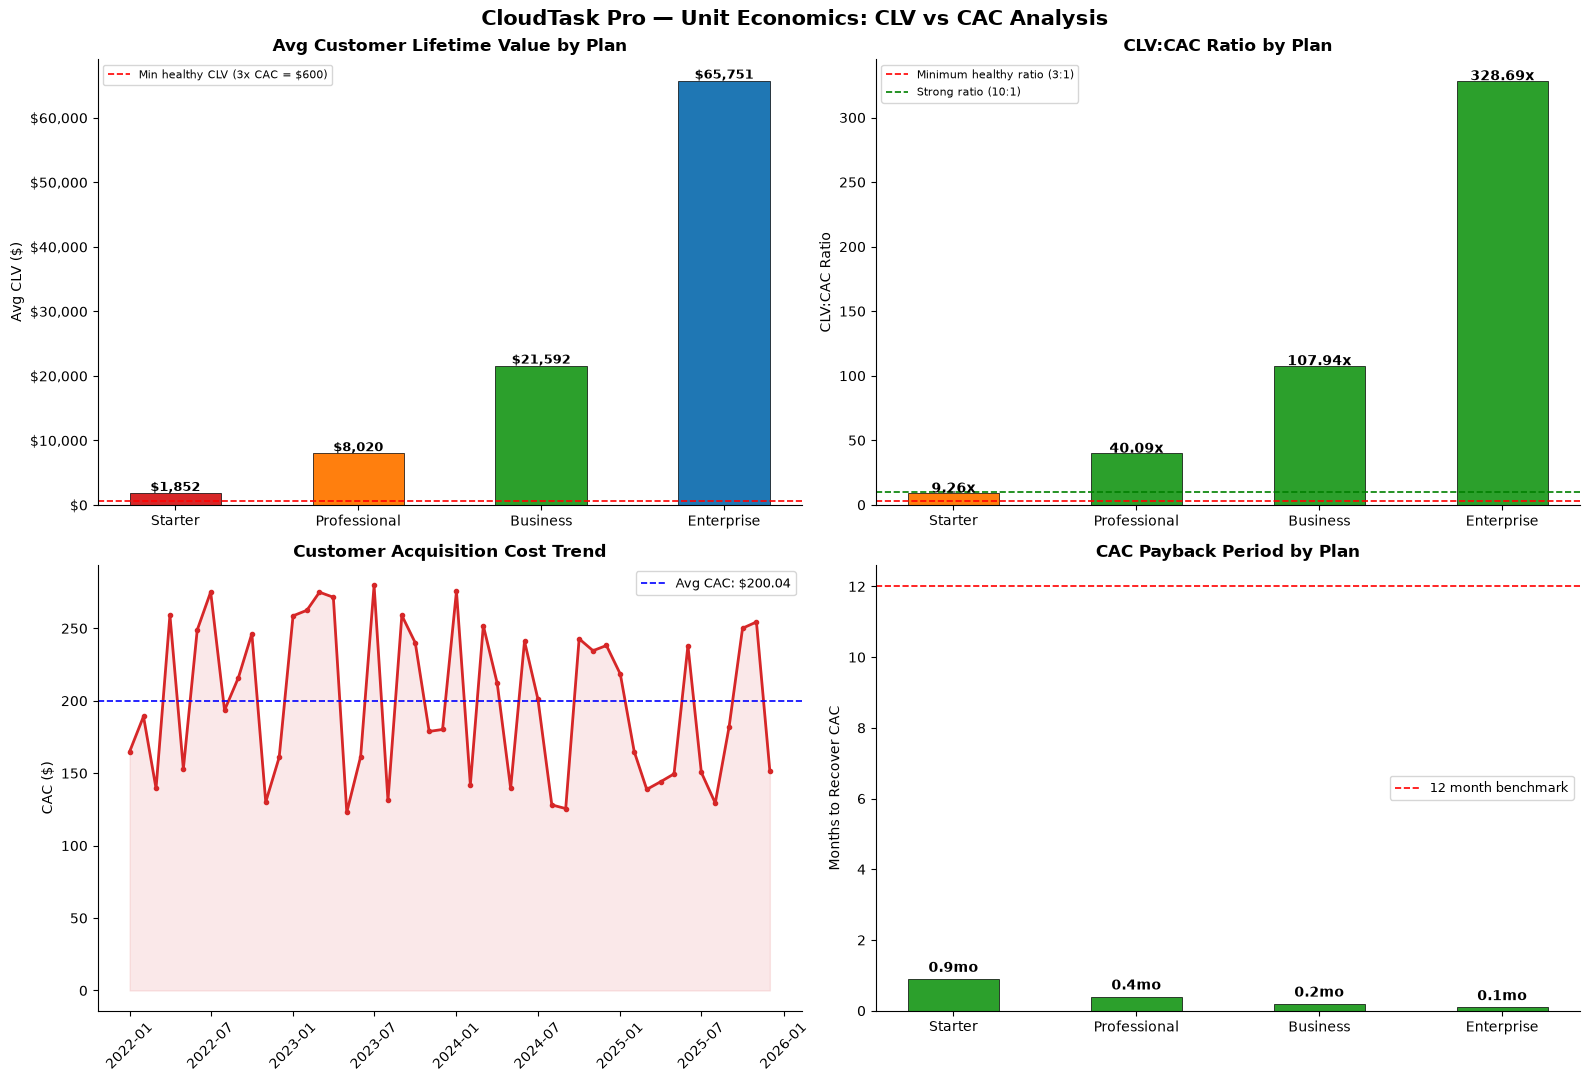

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('CloudTask Pro — Unit Economics: CLV vs CAC Analysis',
             fontsize=15, fontweight='bold')

# ── Panel 1: Avg CLV by Plan ──
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']
bars = axes[0,0].bar(clv_plan['plan'], clv_plan['avg_clv'],
                      color=colors, edgecolor='black',
                      linewidth=0.5, width=0.5)
axes[0,0].axhline(avg_cac * 3, color='red', linestyle='--',
                   linewidth=1.2,
                   label=f'Min healthy CLV (3x CAC = ${avg_cac*3:,.0f})')
for bar, val in zip(bars, clv_plan['avg_clv']):
    axes[0,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 300,
                   f'${val:,.0f}', ha='center',
                   fontsize=9, fontweight='bold')
axes[0,0].set_title('Avg Customer Lifetime Value by Plan',
                     fontweight='bold')
axes[0,0].set_ylabel('Avg CLV ($)')
axes[0,0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0,0].legend(fontsize=8)
axes[0,0].spines['top'].set_visible(False)
axes[0,0].spines['right'].set_visible(False)

# ── Panel 2: CLV:CAC Ratio by Plan ──
ratio_colors = ['#d62728' if x < 3 else '#ff7f0e' if x < 10
                else '#2ca02c' for x in clv_plan['clv_cac_ratio']]
bars2 = axes[0,1].bar(clv_plan['plan'], clv_plan['clv_cac_ratio'],
                       color=ratio_colors, edgecolor='black',
                       linewidth=0.5, width=0.5)
axes[0,1].axhline(3, color='red', linestyle='--',
                   linewidth=1.2, label='Minimum healthy ratio (3:1)')
axes[0,1].axhline(10, color='green', linestyle='--',
                   linewidth=1.2, label='Strong ratio (10:1)')
for bar, val in zip(bars2, clv_plan['clv_cac_ratio']):
    axes[0,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.3,
                   f'{val}x', ha='center',
                   fontsize=10, fontweight='bold')
axes[0,1].set_title('CLV:CAC Ratio by Plan', fontweight='bold')
axes[0,1].set_ylabel('CLV:CAC Ratio')
axes[0,1].legend(fontsize=8)
axes[0,1].spines['top'].set_visible(False)
axes[0,1].spines['right'].set_visible(False)

# ── Panel 3: CAC Trend Over Time ──
axes[1,0].plot(rev['month'],
               rev['customer_acquisition_cost'],
               color='#d62728', linewidth=2,
               marker='o', markersize=3)
axes[1,0].axhline(avg_cac, color='blue', linestyle='--',
                   linewidth=1.2,
                   label=f'Avg CAC: ${avg_cac:,.2f}')
axes[1,0].fill_between(rev['month'],
                        rev['customer_acquisition_cost'],
                        alpha=0.1, color='#d62728')
axes[1,0].set_title('Customer Acquisition Cost Trend',
                     fontweight='bold')
axes[1,0].set_ylabel('CAC ($)')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].legend(fontsize=9)
axes[1,0].spines['top'].set_visible(False)
axes[1,0].spines['right'].set_visible(False)

# ── Panel 4: Payback Period by Plan ──
payback_colors = ['#d62728' if x > 12 else '#ff7f0e' if x > 6
                  else '#2ca02c' for x in clv_plan['payback_months']]
bars4 = axes[1,1].bar(clv_plan['plan'],
                       clv_plan['payback_months'],
                       color=payback_colors,
                       edgecolor='black', linewidth=0.5,
                       width=0.5)
axes[1,1].axhline(12, color='red', linestyle='--',
                   linewidth=1.2, label='12 month benchmark')
for bar, val in zip(bars4, clv_plan['payback_months']):
    axes[1,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.2,
                   f'{val}mo', ha='center',
                   fontsize=10, fontweight='bold')
axes[1,1].set_title('CAC Payback Period by Plan',
                     fontweight='bold')
axes[1,1].set_ylabel('Months to Recover CAC')
axes[1,1].legend(fontsize=9)
axes[1,1].spines['top'].set_visible(False)
axes[1,1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/chart4_clv_cac_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

### 📊 Chart 4 — Unit Economics: CLV vs CAC Insight

**CLV:CAC Ratios (Benchmark: 3:1 minimum, 10:1 strong):**

| Plan | Avg CLV | CLV:CAC | Payback | Verdict |
|---|---|---|---|---|
| Starter | $1,852 | 9.26x | 0.9 mo | 🟠 Acceptable |
| Professional | $8,020 | 40.09x | 0.4 mo | 🟢 Excellent |
| Business | $21,592 | 107.94x | 0.2 mo | 🟢 Outstanding |
| Enterprise | $65,751 | 328.69x | 0.1 mo | 🟢 Extraordinary |

**Key Findings:**
- All plans exceed the 3:1 CLV:CAC benchmark — acquisition
  efficiency is NOT the problem
- Enterprise generates 328x return on $200 acquisition cost —
  single most valuable growth lever available
- CAC is declining year over year ($218 in 2023 → $181 in 2025)
  — marketing efficiency is improving
- All payback periods under 1 month — cash flow is healthy
- The core problem: 52% churn is destroying potential CLV
  before customers reach full lifetime value

**The Churn Math:**
- Churned customers avg lifespan: 9.7 months
- Active customers avg lifespan: 17.8 months
- If churn reduced by 50%, avg lifespan could approach 17+ months
- For Starter alone: 9.7 → 17 months = $1,852 → $3,253 avg CLV
  — a 76% increase in value per customer with zero acquisition spend

**Recommendation:**
- Invest 3x more in Enterprise acquisition — 328x ROI justifies
  aggressive sales spend
- Churn reduction is more valuable than new acquisition —
  every month of additional retention adds $215–$2,985 in CLV
  depending on plan

==Feature Usage:Churned Vs Active
         feature_usage_pct  nps_score  support_tickets_12mo
churned                                                    
No                   55.02       5.81                  5.50
Yes                  27.45       3.04                  7.38

 At Risk Threshold analysis
Threshold <20%: 107 customers, churn rate: 87.9%, active at-risk: 13
Threshold <25%: 169 customers, churn rate: 82.2%, active at-risk: 30
Threshold <30%: 223 customers, churn rate: 81.2%, active at-risk: 42
Threshold <35%: 287 customers, churn rate: 76.7%, active at-risk: 67
Threshold <40%: 350 customers, churn rate: 73.4%, active at-risk: 93

=== CURRENT AT-RISK ACTIVE CUSTOMERS ===
Total active customers  : 287
At-risk (usage < 30%)   : 42
At-risk %               : 14.6%
At-risk MRR at stake    : $38,464.43

At-risk by plan:
              count  mrr_at_stake  avg_feature_usage  avg_nps
plan                                                         
Business         15      20198.00       

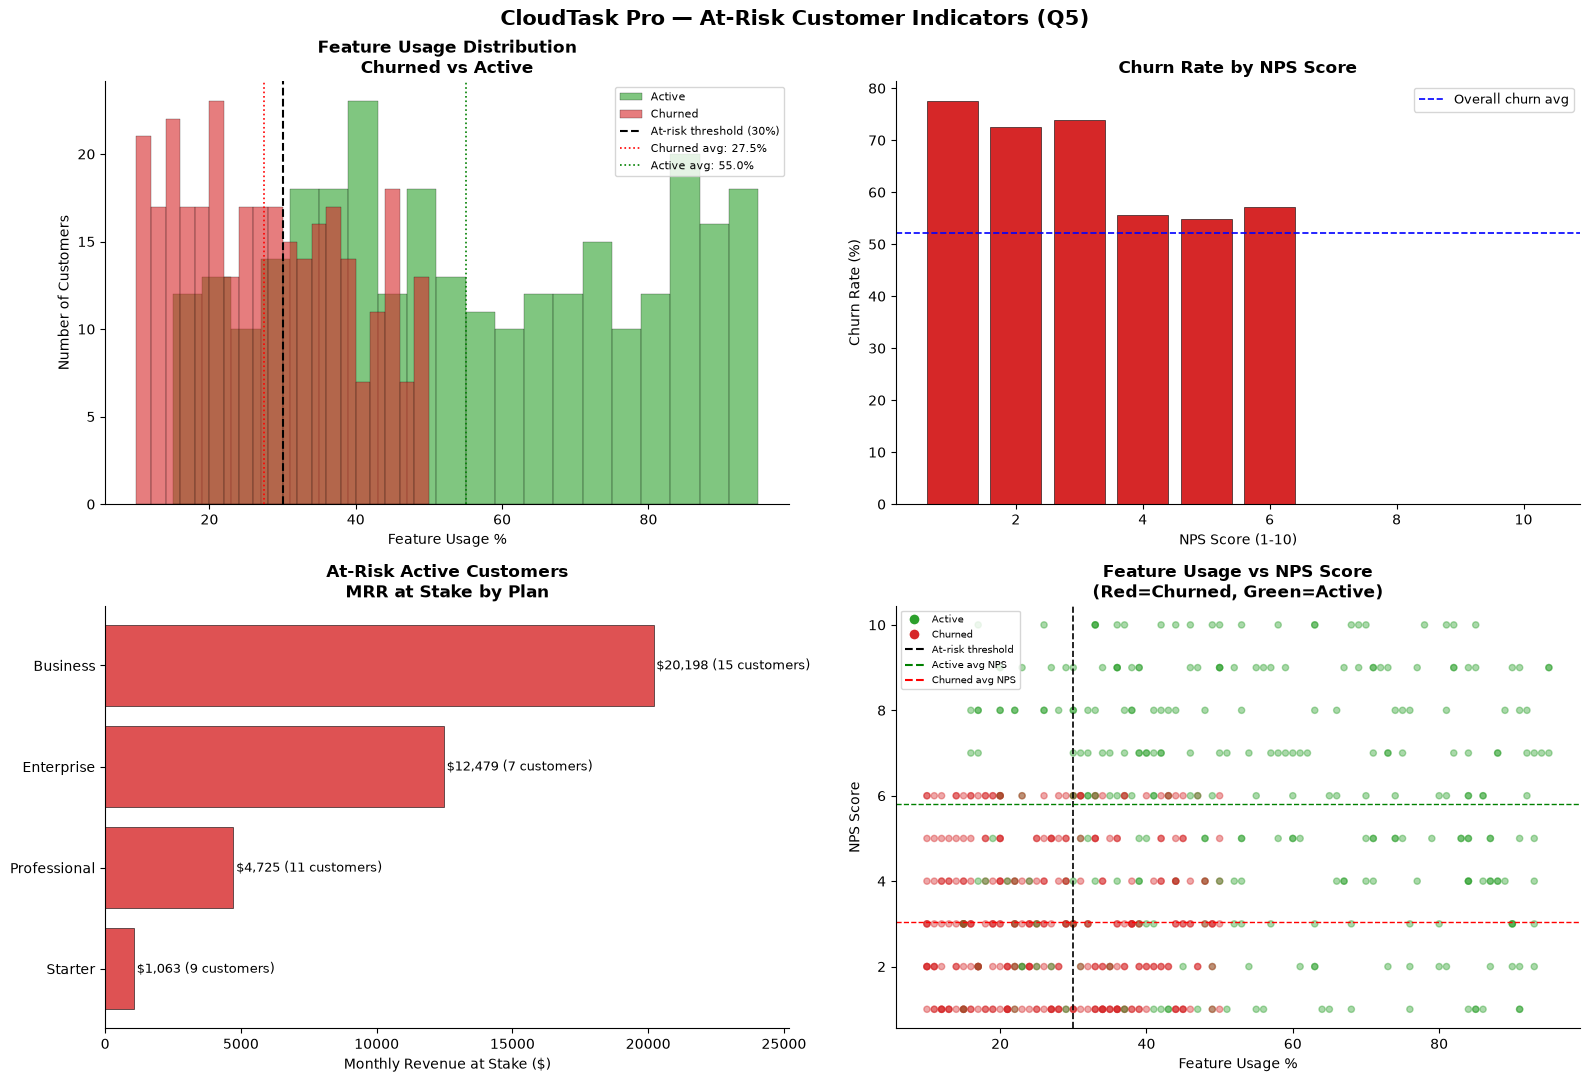

In [18]:
print("==Feature Usage:Churned Vs Active")
print(subs.groupby('churned')[['feature_usage_pct','nps_score','support_tickets_12mo']].mean().round(2))


print("\n At Risk Threshold analysis")
thresholds=[20,25,30,35,40]
for t in thresholds:
    at_risk=subs[subs['feature_usage_pct']<t]
    churn_rate=at_risk['churned_binary'].mean()*100
    active_at_risk=at_risk[at_risk['churned']=='No']
    print(f"Threshold <{t}%: {len(at_risk)} customers, "
          f"churn rate: {churn_rate:.1f}%, "
          f"active at-risk: {len(active_at_risk)}")

at_risk_active = subs[
    (subs['feature_usage_pct'] < 30) &
    (subs['churned'] == 'No')
].copy()

print(f"\n=== CURRENT AT-RISK ACTIVE CUSTOMERS ===")
print(f"Total active customers  : {len(subs[subs['churned']=='No'])}")
print(f"At-risk (usage < 30%)   : {len(at_risk_active)}")
print(f"At-risk %               : {len(at_risk_active)/len(subs[subs['churned']=='No'])*100:.1f}%")
print(f"At-risk MRR at stake    : ${at_risk_active['monthly_revenue'].sum():,.2f}")
print(f"\nAt-risk by plan:")
print(at_risk_active.groupby('plan').agg(
    count=('customer_id', 'count'),
    mrr_at_stake=('monthly_revenue', 'sum'),
    avg_feature_usage=('feature_usage_pct', 'mean'),
    avg_nps=('nps_score', 'mean')
).round(2).to_string())

# NPS VS CHURN analysis
nps_analysis = subs.groupby('nps_score').agg(
    total=('customer_id', 'count'),
    churned=('churned_binary', 'sum')
).reset_index()
nps_analysis['churn_rate_%'] = (
    nps_analysis['churned'] / nps_analysis['total'] * 100
).round(2)

print("\n=== CHURN RATE BY NPS SCORE ===")
print(nps_analysis.to_string(index=False))
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('CloudTask Pro — At-Risk Customer Indicators (Q5)',
             fontsize=15, fontweight='bold')

# ── Panel 1: Feature Usage Distribution Churned vs Active ──
churned_usage = subs[subs['churned']=='Yes']['feature_usage_pct']
active_usage = subs[subs['churned']=='No']['feature_usage_pct']

axes[0,0].hist(active_usage, bins=20, alpha=0.6,
               color='#2ca02c', label='Active', edgecolor='black',
               linewidth=0.3)
axes[0,0].hist(churned_usage, bins=20, alpha=0.6,
               color='#d62728', label='Churned', edgecolor='black',
               linewidth=0.3)
axes[0,0].axvline(30, color='black', linestyle='--',
                   linewidth=1.5, label='At-risk threshold (30%)')
axes[0,0].axvline(churned_usage.mean(), color='red',
                   linestyle=':', linewidth=1.2,
                   label=f'Churned avg: {churned_usage.mean():.1f}%')
axes[0,0].axvline(active_usage.mean(), color='green',
                   linestyle=':', linewidth=1.2,
                   label=f'Active avg: {active_usage.mean():.1f}%')
axes[0,0].set_title('Feature Usage Distribution\nChurned vs Active',
                     fontweight='bold')
axes[0,0].set_xlabel('Feature Usage %')
axes[0,0].set_ylabel('Number of Customers')
axes[0,0].legend(fontsize=8)
axes[0,0].spines['top'].set_visible(False)
axes[0,0].spines['right'].set_visible(False)

# ── Panel 2: NPS vs Churn Rate ──
axes[0,1].bar(nps_analysis['nps_score'],
               nps_analysis['churn_rate_%'],
               color=['#d62728' if x > 50 else '#ff7f0e' if x > 30
                      else '#2ca02c'
                      for x in nps_analysis['churn_rate_%']],
               edgecolor='black', linewidth=0.4)
axes[0,1].axhline(52.17, color='blue', linestyle='--',
                   linewidth=1.2, label='Overall churn avg')
axes[0,1].set_title('Churn Rate by NPS Score', fontweight='bold')
axes[0,1].set_xlabel('NPS Score (1-10)')
axes[0,1].set_ylabel('Churn Rate (%)')
axes[0,1].legend(fontsize=9)
axes[0,1].spines['top'].set_visible(False)
axes[0,1].spines['right'].set_visible(False)

# ── Panel 3: At-Risk Active Customers by Plan ──
at_risk_plan = at_risk_active.groupby('plan').agg(
    at_risk_count=('customer_id', 'count'),
    mrr_at_stake=('monthly_revenue', 'sum')
).reset_index().sort_values('mrr_at_stake', ascending=True)

bars3 = axes[1,0].barh(at_risk_plan['plan'],
                        at_risk_plan['mrr_at_stake'],
                        color='#d62728', edgecolor='black',
                        linewidth=0.5, alpha=0.8)
for bar, count, val in zip(bars3,
                            at_risk_plan['at_risk_count'],
                            at_risk_plan['mrr_at_stake']):
    axes[1,0].text(val + 100,
                   bar.get_y() + bar.get_height()/2,
                   f'${val:,.0f} ({count} customers)',
                   va='center', fontsize=9)
axes[1,0].set_title('At-Risk Active Customers\nMRR at Stake by Plan',
                     fontweight='bold')
axes[1,0].set_xlabel('Monthly Revenue at Stake ($)')
axes[1,0].set_xlim(0, at_risk_plan['mrr_at_stake'].max() + 5000)
axes[1,0].spines['top'].set_visible(False)
axes[1,0].spines['right'].set_visible(False)

# ── Panel 4: Feature Usage vs NPS Scatter ──
scatter_colors = subs['churned_binary'].map({0: '#2ca02c', 1: '#d62728'})
axes[1,1].scatter(subs['feature_usage_pct'], subs['nps_score'],
                   c=scatter_colors, alpha=0.4, s=20)
axes[1,1].axvline(30, color='black', linestyle='--',
                   linewidth=1.2, label='At-risk threshold (30%)')
axes[1,1].axhline(subs[subs['churned']=='No']['nps_score'].mean(),
                   color='green', linestyle='--',
                   linewidth=1, label='Active avg NPS')
axes[1,1].axhline(subs[subs['churned']=='Yes']['nps_score'].mean(),
                   color='red', linestyle='--',
                   linewidth=1, label='Churned avg NPS')

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='#2ca02c', markersize=8, label='Active'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='#d62728', markersize=8, label='Churned')
]
axes[1,1].legend(handles=legend_elements +
                 [Line2D([0], [0], color='black', linestyle='--',
                         label='At-risk threshold'),
                  Line2D([0], [0], color='green', linestyle='--',
                         label='Active avg NPS'),
                  Line2D([0], [0], color='red', linestyle='--',
                         label='Churned avg NPS')],
                 fontsize=7)
axes[1,1].set_title('Feature Usage vs NPS Score\n(Red=Churned, Green=Active)',
                     fontweight='bold')
axes[1,1].set_xlabel('Feature Usage %')
axes[1,1].set_ylabel('NPS Score')
axes[1,1].spines['top'].set_visible(False)
axes[1,1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/chart5_at_risk_indicators.png',
            dpi=150, bbox_inches='tight')
plt.show()
    

### 📊 Chart 5 — At-Risk Customer Indicators

**Feature Usage Thresholds:**
| Threshold | Customers | Churn Rate | Active At-Risk |
|---|---|---|---|
| Below 20% | 107 | 87.9% 🔴 | 13 |
| Below 25% | 169 | 82.2% 🔴 | 30 |
| Below 30% | 223 | 81.2% 🔴 | 42 |
| Below 35% | 287 | 76.7% 🟠 | 67 |
| Below 40% | 350 | 73.4% 🟠 | 93 |

**Recommended threshold: 30% feature usage**
- Captures 81.2% of churners
- Flags 42 active customers = $38,464 MRR at risk
- Annualized risk: ~$461,573 ARR

**NPS Score — Perfect Churn Divider:**
| NPS Range | Churn Rate |
|---|---|
| 1–3 | 72–77% 🔴 |
| 4–6 | 54–57% 🟠 |
| 7–10 | 0.00% ✅ |

Zero customers with NPS ≥ 7 have churned.
NPS score is a near-perfect leading indicator of retention.

**Current At-Risk MRR by Plan:**
| Plan | Customers | MRR at Stake |
|---|---|---|
| Business | 15 | $20,198 🔴 |
| Enterprise | 7 | $12,479 🔴 |
| Professional | 11 | $4,725 🟠 |
| Starter | 9 | $1,063 🟠 |
| **Total** | **42** | **$38,464** |

**At-Risk Early Warning System — Flag customers when:**
1. Feature usage drops below 30% → immediate CS outreach
2. NPS score ≤ 6 → schedule health check call
3. Support tickets > 10 in 12 months → escalate to senior support
4. All three present simultaneously → executive intervention

**Recommendation:**
Implement a customer health score combining all three signals.
Priority intervention on 22 Business + Enterprise customers
with $32,677 MRR at stake — each saved customer worth
$21,592–$65,751 in CLV.